In [1]:
print("Name - Arpit Verma\n")
print("Roll No - 2401641530048\n")
print("Class - CS AIML ELITE 3A")

Name - Arpit Verma

Roll No - 2401641530048

Class - CS AIML ELITE 3A


***Regression Analysis using California Housing Dataset***

1. Import the libraries 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

2. Loading the Dataset

In [3]:
# Load Independent Variables
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

#Load  independent features into a pandas dataframe
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal']=housing.target

PART A - DATASET HANDLING

Finding the 10 records from top of the data 

In [4]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


--Checking the shape of the data row and colums

In [5]:
df.shape

(20640, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

There is not any null value which is present in the dataset

The dataset contains 20,640 observations and 9 numerical variables, including the target variable. All attributes are stored as floating-point values, making them immediately suitable for statistical analysis. Descriptive statistics such as mean, standard deviation, minimum, maximum, and quartiles provide an overview of each feature's distribution.

----------Detecting Outliers using IQR TEST METHOD-----------

In [9]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Visualizing the boxplots for detecting the outliers

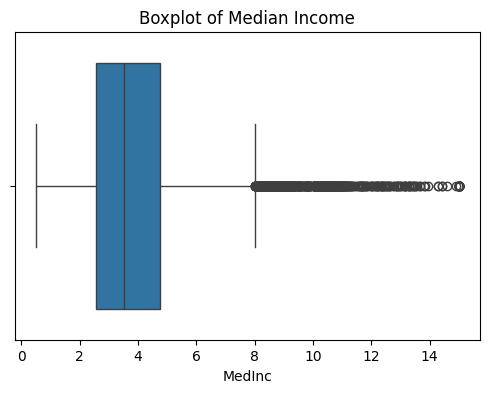

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["MedInc"])
plt.title("Boxplot of Median Income")
plt.show()

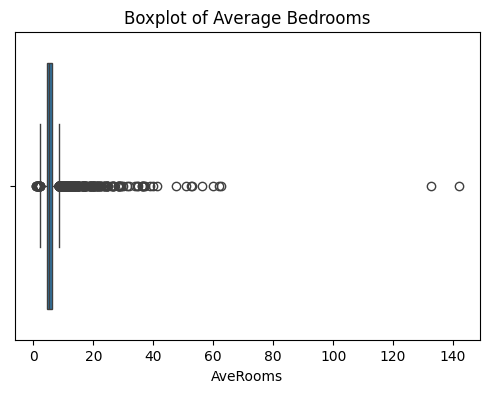

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['AveRooms'])
plt.title("Boxplot of Average Bedrooms")
plt.show()

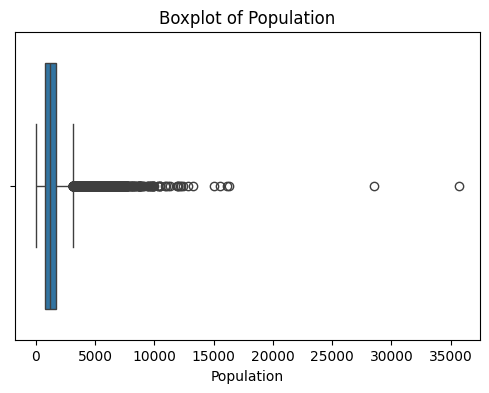

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Population'])
plt.title("Boxplot of Population")
plt.show()

IQR Testing for the MedInc,Population,AvgBedrooms

In [13]:

Q1 = df["MedInc"].quantile(0.25)
Q3 = df["MedInc"].quantile(0.75)


IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)


outliers = df[
    (df["MedInc"] < lower_bound) |
    (df["MedInc"] > upper_bound)
]

print("Number of Outliers in MedInc:", len(outliers))
print("Percentage:", round((len(outliers)/len(df))*100,2), "%")

Number of Outliers in MedInc: 681
Percentage: 3.3 %


Using the IQR method, 681 outliers were found in the MedInc (Median Income) feature. These outliers are mostly higher income values that lie outside the upper IQR limit. Since these values represent actual observations and are not data entry errors, they are retained for further analysis.

------IQR Test for the analysis of Average Bedrooms-----------

In [14]:

Q1 = df["AveRooms"].quantile(0.25)
Q3 = df["AveRooms"].quantile(0.75)


IQR = Q3 - Q1


lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)


outliers = df[
    (df["AveRooms"] < lower_bound) |
    (df["AveRooms"] > upper_bound)
]

print("Number of Outliers in AveRooms:", len(outliers))
print("Percentage:", round((len(outliers)/len(df))*100,2), "%")

Number of Outliers in AveRooms: 511
Percentage: 2.48 %


In [15]:
Q1 = df["Population"].quantile(0.25)
Q3 = df["Population"].quantile(0.75)


IQR = Q3 - Q1


lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)


outliers = df[
    (df["Population"] < lower_bound) |
    (df["Population"] > upper_bound)
]

print("Number of Outliers in Population:", len(outliers))
print("Percentage:", round((len(outliers)/len(df))*100,2), "%")

Number of Outliers in Population: 1196
Percentage: 5.79 %


The IQR method identified outliers in the MedInc, AveRooms, and Population features. These outliers represent observations in the dataset rather than data entry errors.

The percentage of the outliers is small lessthan 6% where we select each feature these feature will affect our dataset removing them may reduce our model performance by reducing extreme values

**Part B: Exploratory Data Analysis**

In [16]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Checking the columns label

In [17]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Plotting the histogram for the distribution analysis of the Target data

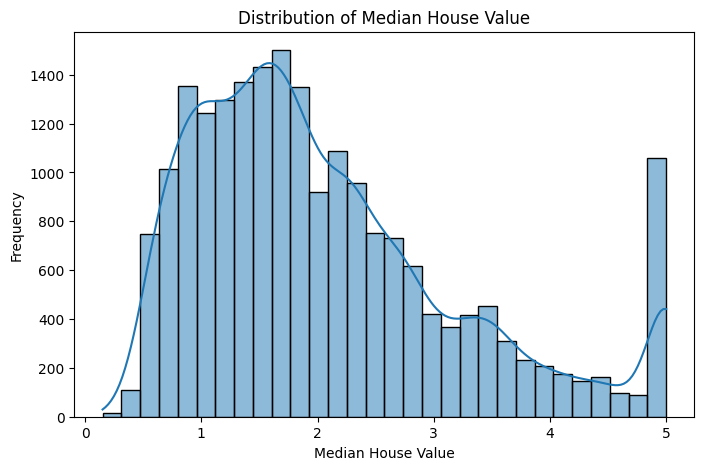

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], bins=30, kde=True)

plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

Checking the skewness whether the data distribution is right skewed or left skewed

In [19]:
df['MedHouseVal'].skew()

np.float64(0.9777632739098335)

The target variable MedHouseVal has a skewness value of 0.97, indicating a positive skewed distribution. The histogram shows that most observations are concentrated at lower values, while a few high-priced houses create a long right tail.

In [20]:
df['MedHouseVal'].describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

In [21]:
df['MedHouseVal'].isnull().sum()

np.int64(0)

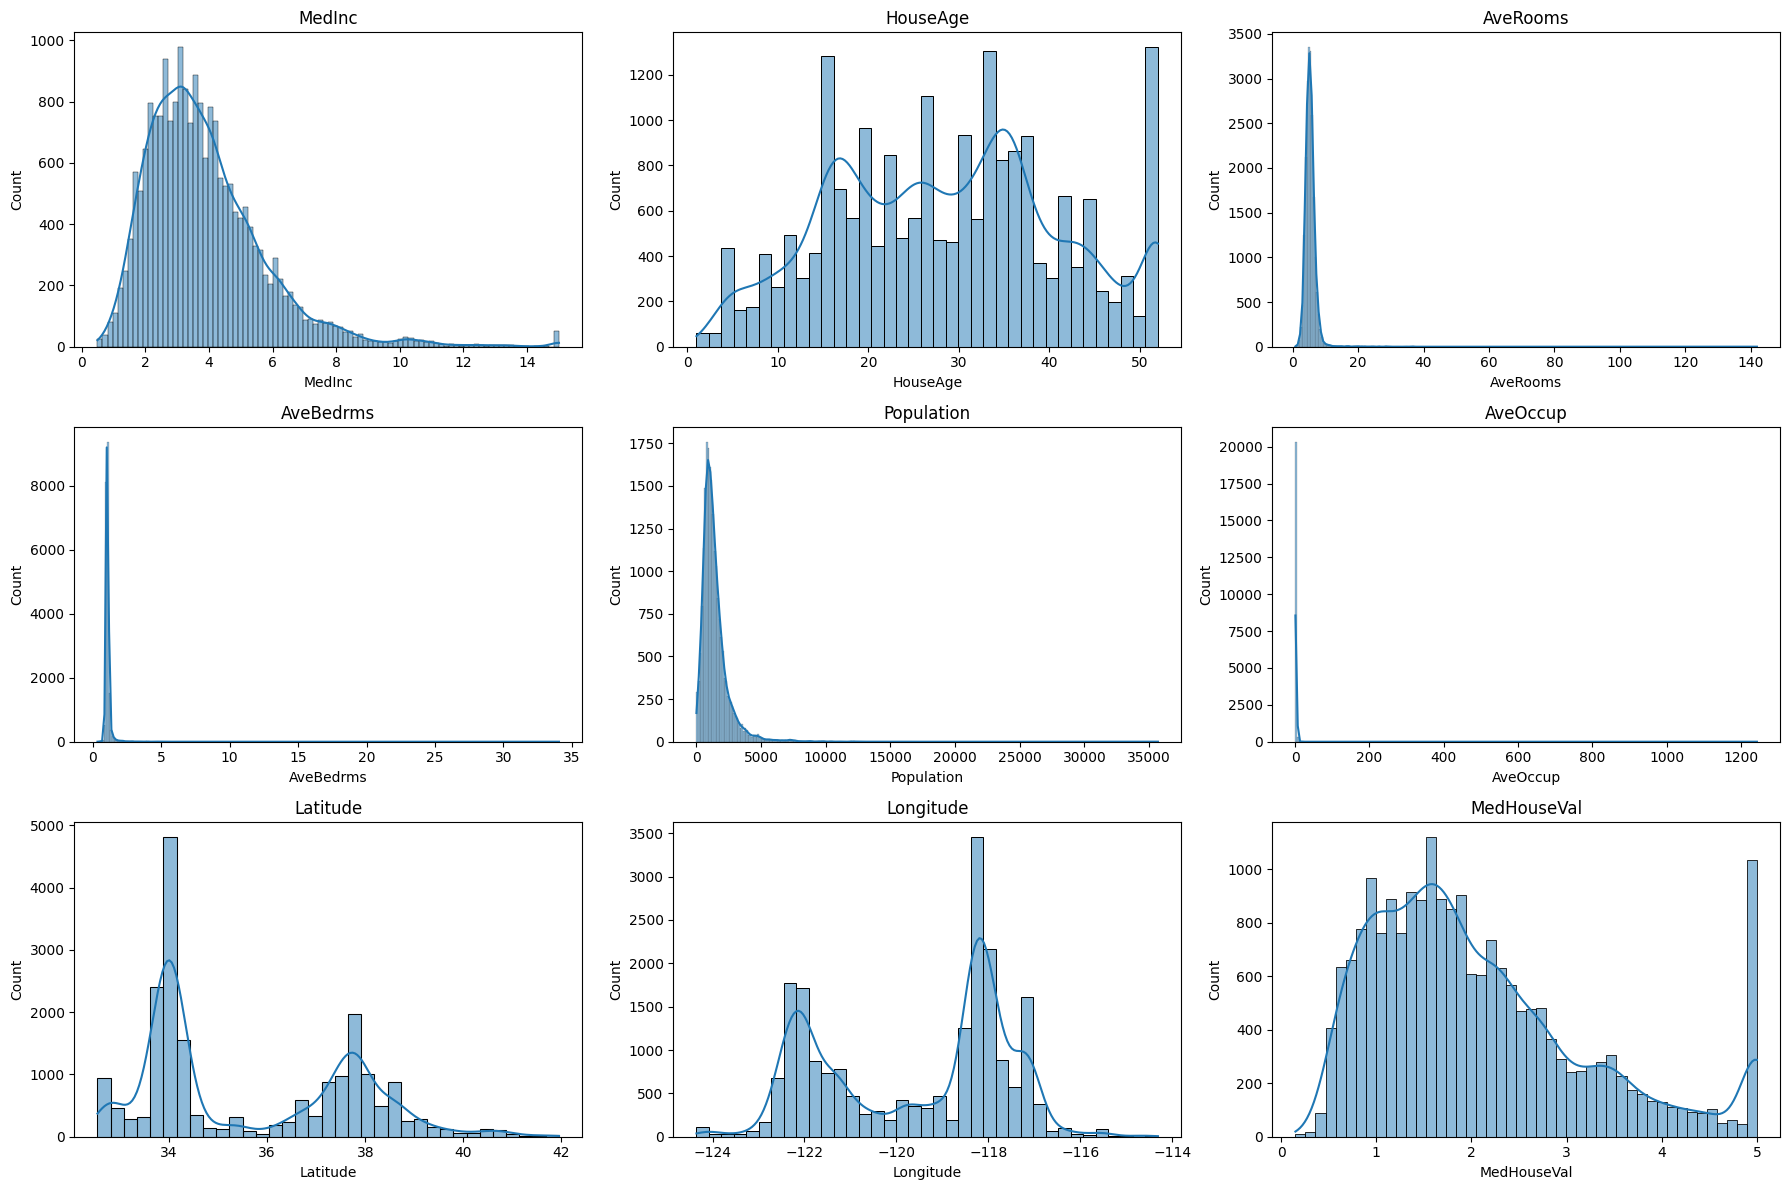

In [22]:
plt.figure(figsize=(18,12))
for i,col in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

The MedInc feature is positively skewed. Most values are concentrated between 2 and 6, while a few higher income values create a long right tail.

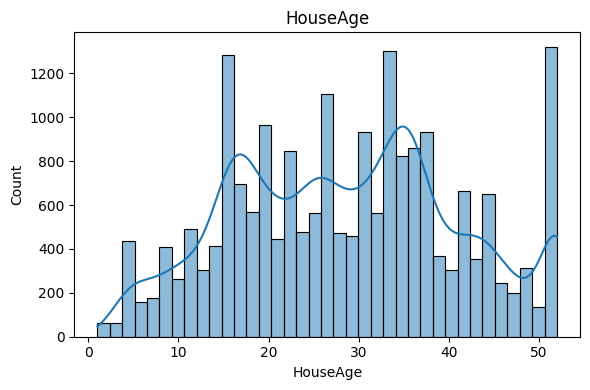

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df['HouseAge'],kde=True)
plt.title('HouseAge')
plt.tight_layout()
plt.show()

The HouseAge feature is not normally distributed. The values are spread across different age groups, and no strong skewness is observed.

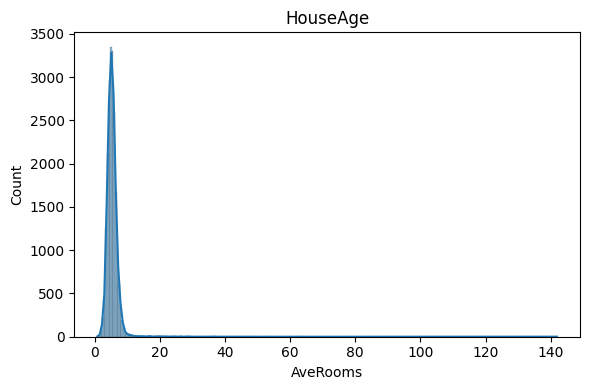

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df['AveRooms'],kde=True)
plt.title('HouseAge')
plt.tight_layout()
plt.show()

The AveRooms feature is highly positively skewed. Most houses have a small average number of rooms, while a few houses have very large numbers of rooms, creating a long right tail.

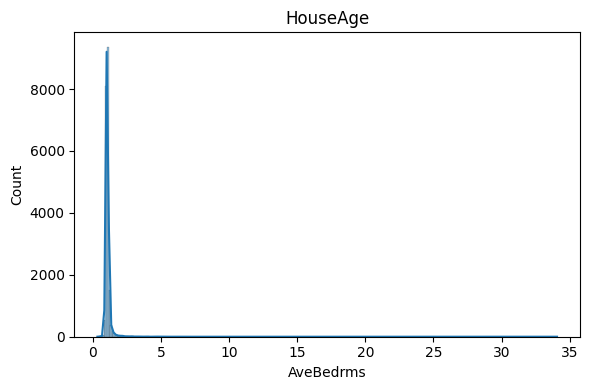

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df['AveBedrms'],kde=True)
plt.title('HouseAge')
plt.tight_layout()
plt.show()

The AveBedrms feature is also highly positively skewed. Most observations are concentrated at lower values, with a few extreme values on the higher side.

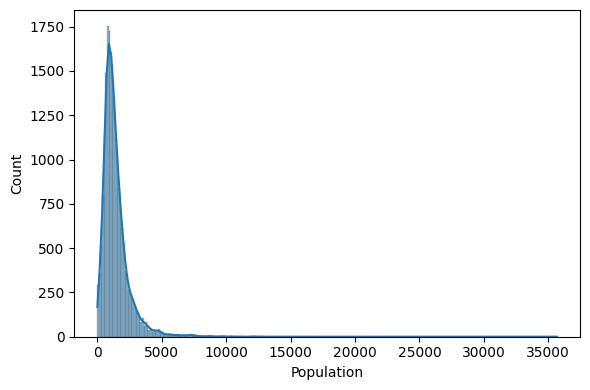

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df['Population'],kde=True)
plt.tight_layout()
plt.show()

The Population feature shows a high positive skew. Most block groups have a smaller population, while a few have a very large population.

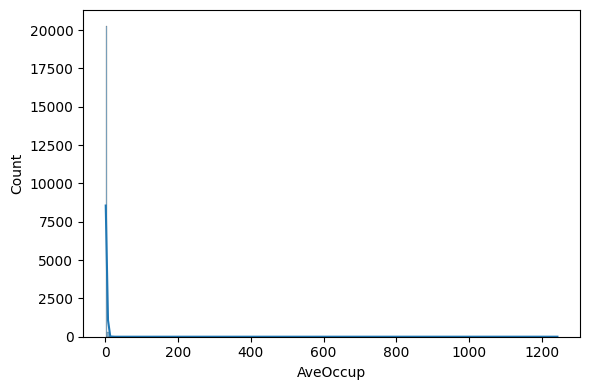

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df['AveOccup'],kde=True)
plt.tight_layout()
plt.show()

The AveOccup feature is extremely positively skewed. Most observations are clustered at lower occupancy values, but a few block groups have very high occupancy

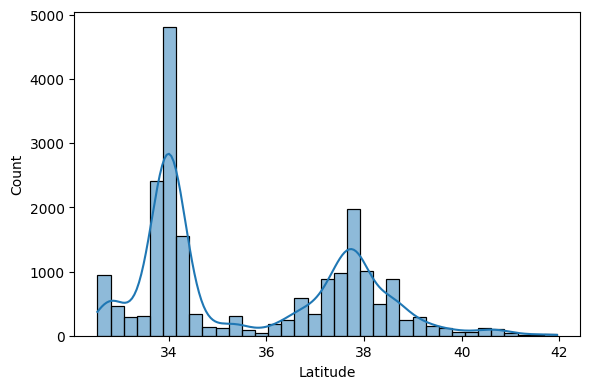

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df['Latitude'],kde=True)
plt.tight_layout()
plt.show()

The Latitude feature is not normally distributed. The values are concentrated around certain latitude ranges, indicating that houses are located in specific geographic regions.

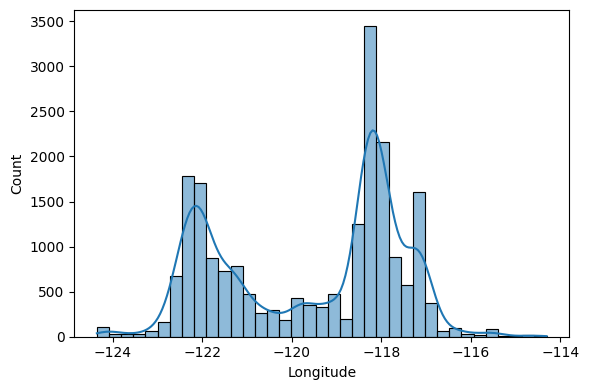

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df['Longitude'],kde=True)
plt.tight_layout()
plt.show()

The Longitude feature is not normally distributed. The distribution has multiple peaks because houses are concentrated in different regions of California.

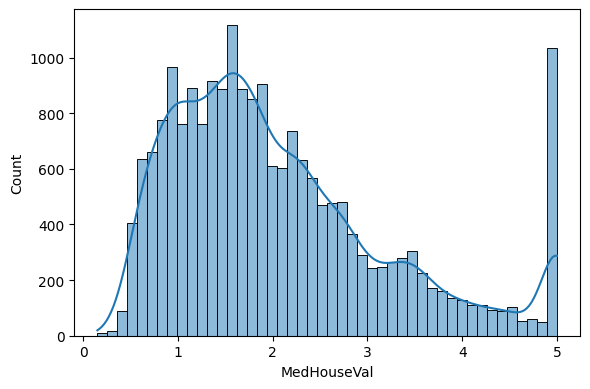

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(df['MedHouseVal'],kde=True)
plt.tight_layout()
plt.show()

he MedHouseVal feature is positively skewed. Most houses have lower to medium prices, while only a few houses have very high prices.

Most numerical features in the California Housing dataset are positively skewed. Features such as MedInc, AveRooms, AveBedrms, Population, AveOccup, and MedHouseVal contain long right tails due to the presence of high-value observations. On the other hand, Latitude, Longitude, and HouseAge do not follow a normal distribution and show clustering based on geographic locations and housing characteristics.

In [31]:
import warnings
warnings.filterwarnings('ignore')

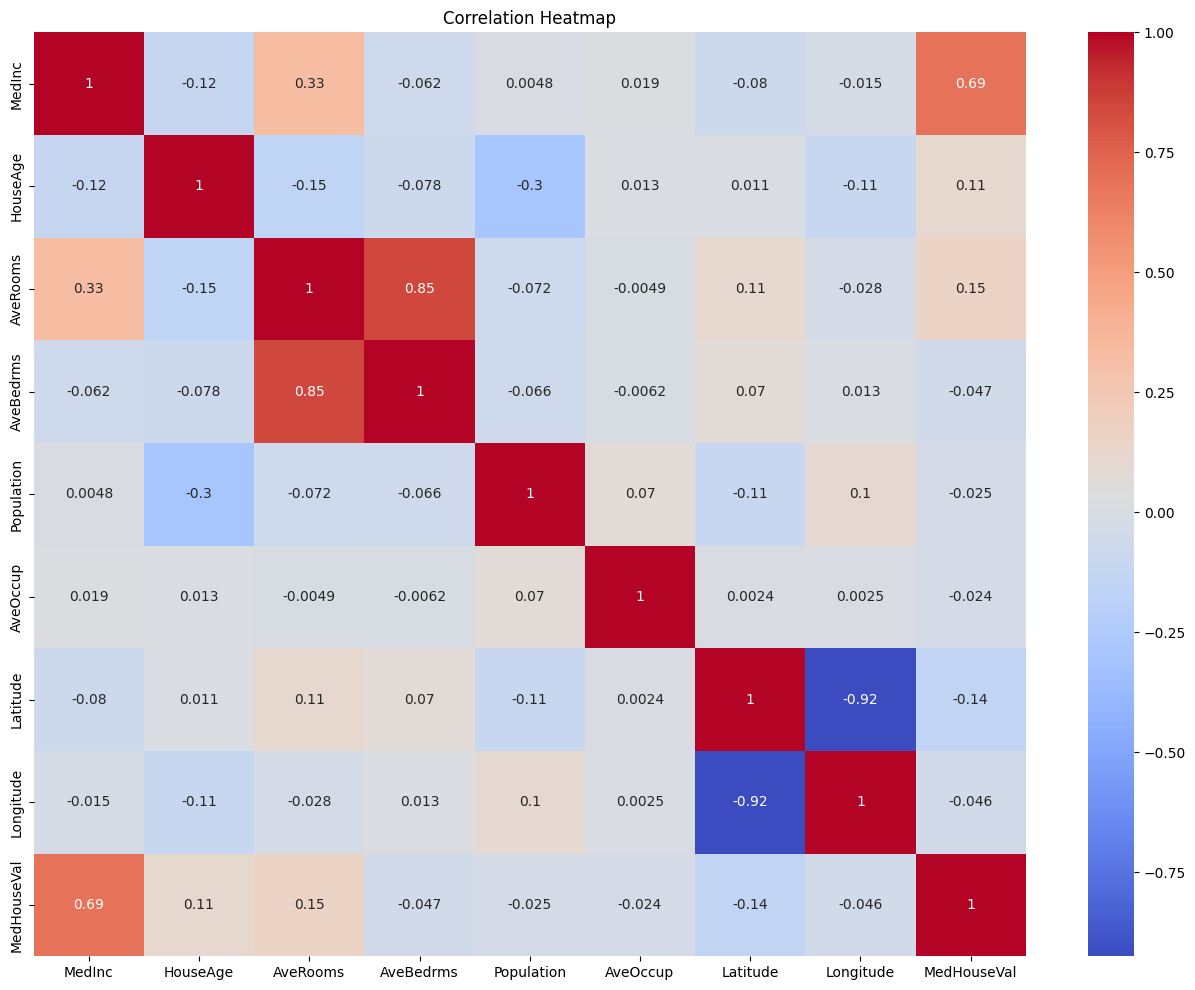

In [32]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [33]:
corr=df.corr()

In [34]:
corr["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

The correlation analysis was performed to identify the relationship between the independent features and the target variable (MedHouseVal). The results show that MedInc has the strongest positive correlation with the target variable, indicating that median income is the most important factor affecting house prices. AveRooms also shows a positive correlation, suggesting that houses with more rooms generally have higher values.

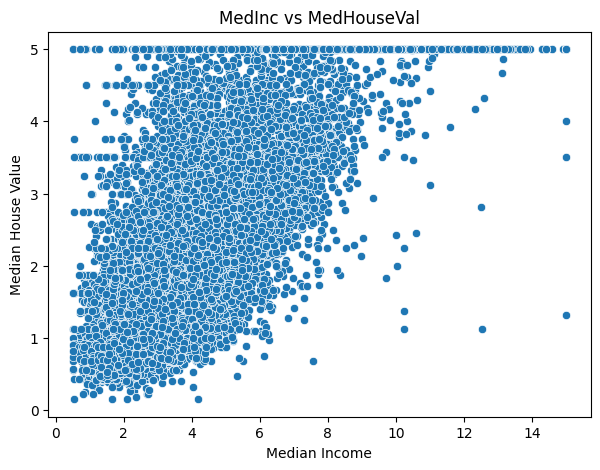

In [35]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["MedInc"], y=df["MedHouseVal"])

plt.title("MedInc vs MedHouseVal")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

--The scatter plot shows a positive relationship between MedInc and MedHouseVal. As the median income increases, the median house value also tends to increase. This indicates that areas with higher income generally have more expensive houses.

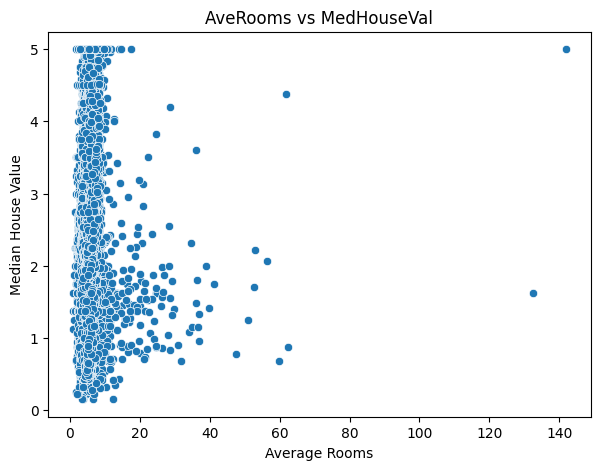

In [36]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["AveRooms"], y=df["MedHouseVal"])

plt.title("AveRooms vs MedHouseVal")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")

plt.show()

--The scatter plot shows a slight positive relationship between AveRooms and MedHouseVal. Houses with more average rooms generally have higher prices, but the relationship is weaker than MedInc.

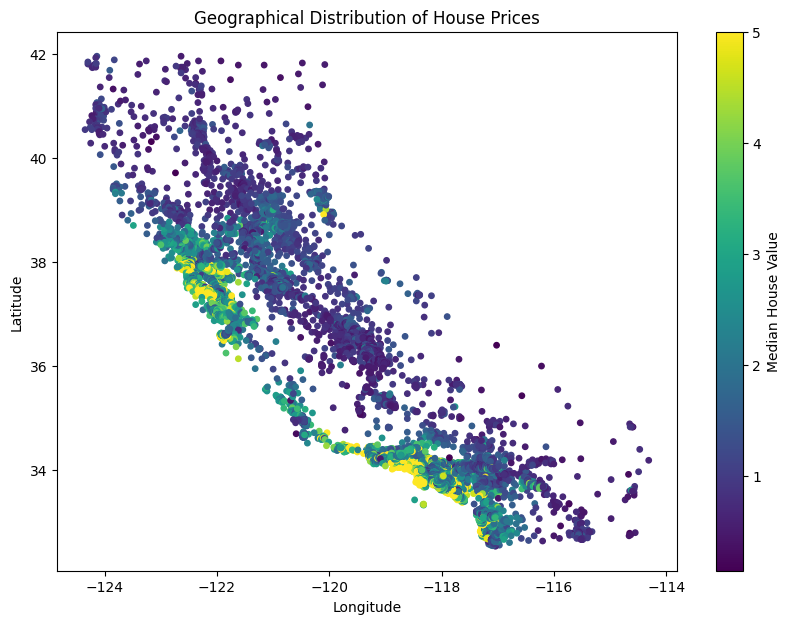

In [37]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="viridis",
    s=15
)

plt.colorbar(scatter, label="Median House Value")

plt.title("Geographical Distribution of House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

The geographical scatter plot shows that house prices are not uniformly distributed across California. Higher house prices are mainly concentrated near the coastal regions, while lower house prices are more common in inland areas. This indicates that location plays an important role in determining house prices.

Part C - Feature Engineering & Preprocessing

In [38]:
df["Bedrooms_per_Room"] = df["AveBedrms"] / df["AveRooms"]

df[["AveRooms","AveBedrms","Bedrooms_per_Room"]].head()

,AveRooms,AveBedrms,Bedrooms_per_Room
0,6.984127,1.023810,0.146591
1,6.238137,0.971880,0.155797
2,8.288136,1.073446,0.129516
3,5.817352,1.073059,0.184458
4,6.281853,1.081081,0.172096


In [39]:
df["Rooms_per_Person"] = df["AveRooms"] / df["Population"]


We will apply log transformation to the feature which is heavily skewed as per the analysis we done we have **Population** which is heavily skewed 

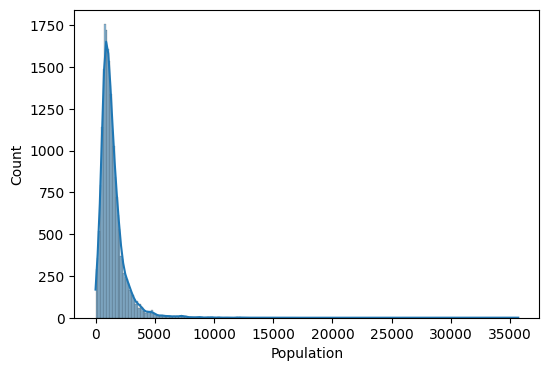

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(df['Population'],kde=True)
plt.show()

We are using np.log1p() as it handles zero values safely

In [41]:
import numpy as np

df["Population_Log"] = np.log1p(df["Population"])

Analysis After Transformation-----

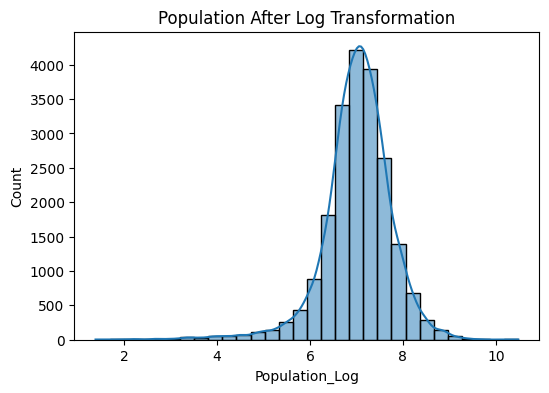

In [42]:
plt.figure(figsize=(6,4))
sns.histplot(df["Population_Log"], bins=30, kde=True)

plt.title("Population After Log Transformation")
plt.show()

Comparing both the distributions Before Log Transformation and After Log Transformation

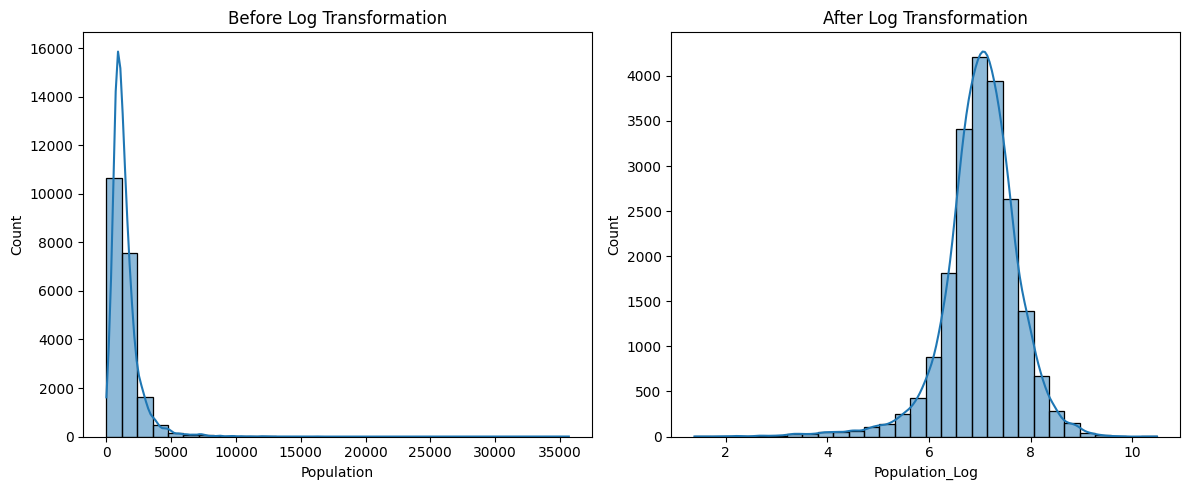

In [43]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Population"], bins=30, kde=True)
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
sns.histplot(df["Population_Log"], bins=30, kde=True)
plt.title("After Log Transformation")

plt.tight_layout()
plt.show()

In [44]:
print("Value before log transformation :",df['Population'].skew())
print("Value after log transformation :",df['Population_Log'].skew())

Value before log transformation : 4.935858226727124
Value after log transformation : -1.0440866961519721


The Population feature was highly positively skewed. A log transformation (log1p) was applied to reduce the effect of extreme values. After the transformation, the skewness changed from positive to approximately -1.04

In [45]:
X = df.drop("MedHouseVal", axis=1)
y=df['MedHouseVal']

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42
)

In [48]:
print("Training Features:",X_train.shape)
print("Testing Features:",X_test.shape)
print("---------------------------------------------")
print("Training Target:",y_train.shape)
print("Testing Target:",y_test.shape)

Training Features: (16512, 11)
Testing Features: (4128, 11)
---------------------------------------------
Training Target: (16512,)
Testing Target: (4128,)


The dataset was divided into 80% training data and 20% testing data using the train_test_split() function with random_state=42

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
print(X_train_scaled)

[[-0.326196    0.34849025 -0.17491646 ... -0.2117846  -0.1215667
   0.97210868]
 [-0.03584338  1.61811813 -0.40283542 ...  0.34218528 -0.09904248
   0.21062259]
 [ 0.14470145 -1.95271028  0.08821601 ... -0.66165785 -0.04810176
  -0.28147975]
 ...
 [-0.49697313  0.58654547 -0.60675918 ...  0.99951387 -0.11993208
   0.60499949]
 [ 0.96545045 -1.07984112  0.40217517 ... -0.79086209 -0.09546136
   0.62116991]
 [-0.68544764  1.85617335 -0.85144571 ...  1.69520292 -0.13781891
   1.14880727]]


In [51]:
print(X_test_scaled)

[[-1.15508475 -0.28632369 -0.52068576 ...  0.53446979 -0.10627872
   0.28904721]
 [-0.70865905  0.11043502 -0.16581537 ...  0.4134107  -0.1024401
   0.44837189]
 [-0.21040155  1.85617335 -0.61076476 ...  1.47109849 -0.1058301
   0.20647637]
 ...
 [ 2.80902421 -0.28632369  0.75501156 ... -1.41376846 -0.07764364
   0.46564362]
 [-0.57542978  0.58654547 -0.06124296 ... -0.46519652 -0.08235537
   0.11746275]
 [-0.17259111 -0.92113763 -0.6058703  ...  0.79725091 -0.11778163
   0.53751146]]


Both the values are in numpy array we convert them into dataframe format

In [52]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)

X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [53]:
X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Bedrooms_per_Room,Rooms_per_Person,Population_Log
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587,-0.211785,-0.121567,0.972109
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162,0.342185,-0.099042,0.210623
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603,-0.661658,-0.048102,-0.281480
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698,0.783032,-0.109756,0.314216
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551,-0.550364,-0.029650,-0.343803


In [54]:
X_train_scaled.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Bedrooms_per_Room,Rooms_per_Person,Population_Log
count,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,16512.000000,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04
mean,-6.411753e-17,-1.678244e-17,1.790127e-16,-6.893710e-16,0.000000,1.032766e-17,3.385750e-15,1.776787e-15,-5.852338e-17,1.204893e-17,3.287637e-16
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.775438e+00,-2.190766e+00,-1.904386e+00,-1.762117e+00,-1.251913,-2.076846e-01,-1.447697e+00,-2.377207e+00,-1.946041e+00,-1.590271e-01,-7.676745e+00
25%,-6.900689e-01,-8.417859e-01,-4.118373e-01,-2.081645e-01,-0.560634,-5.770769e-02,-8.018107e-01,-1.110749e+00,-6.497310e-01,-1.093534e-01,-4.828844e-01
50%,-1.758995e-01,3.108328e-02,-8.350905e-02,-1.094160e-01,-0.228186,-2.415892e-02,-6.473597e-01,5.346501e-01,-1.733004e-01,-8.009162e-02,4.928517e-02
75%,4.686502e-01,6.658972e-01,2.621376e-01,8.455177e-03,0.263449,1.580865e-02,9.720351e-01,7.839530e-01,4.594195e-01,-3.436903e-02,5.815604e-01
max,5.839268e+00,1.856173e+00,5.716655e+01,5.664727e+01,30.127428,1.071164e+02,2.951816e+00,2.628794e+00,1.357290e+01,8.696181e+01,4.703044e+00


The features were standardized using the StandardScaler technique. After scaling, the mean of all features is approximately 0, and the standard deviation is approximately 1.

Feature Engineering
↓
Log Transformation
↓
Scaling
↓
Model

This is step by step we combine multiple preprocessing steps into the single pipeline

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [56]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [57]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [58]:
y_pred=pipeline.predict(X_test)

**Part D - Model Development, Training, and Testing**

In [59]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Checking the model coefficients

In [60]:
print("Intercept:", model.intercept_)

Intercept: 2.0719469373788804


In [61]:
print("Coefficients:", model.coef_)

Coefficients: [ 8.45412125e-01  1.23517520e-01  5.33676606e-02  4.68440361e-02
 -6.85376217e-04 -4.14978175e-02 -8.78753136e-01 -8.57781344e-01
  2.06185282e-01 -2.13964953e-02 -6.84300247e-03]


In [62]:
y_pred=model.predict(X_test_scaled)
y_pred

array([0.71573425, 1.72850736, 2.74600069, ..., 4.51334489, 1.16190359,
       2.00072947], shape=(4128,))

In [63]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: MedHouseVal, Length: 4128, dtype: float64

A Linear Regression model was created and trained using the standardized training dataset. The model learned the relationship between the independent variables and the target variable (MedHouseVal). After training, predictions were generated for the testing dataset.

--------------Part E - Model Performance Assessment-------------------

We use four evaluation metrics:

-MAE (Mean Absolute Error)
-MSE (Mean Squared Error)
-RMSE (Root Mean Squared Error)
-R² Score (Coefficient of Determination)

In [64]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [65]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error", mae)


Mean Absolute Error 0.5256612758499531


In [66]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.5301172580841353


Calculating RMSE

In [67]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.7280915176570424


Calculating R2 score

In [68]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5954566346181727


In [69]:
print("Model Evaluation")
print("-" * 30)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
------------------------------
MAE  : 0.5257
MSE  : 0.5301
RMSE : 0.7281
R²   : 0.5955


The Linear Regression model was evaluated using MAE, MSE, RMSE, and R² Score. The model achieved an MAE of 0.5257, indicating that the average prediction error is about 0.53. The RMSE of 0.7281 shows that the model's predictions are reasonably close to the actual values. The R² Score is 0.5955, which means the model explains approximately 59.55% of the variation in house prices. Overall, the model provides moderate prediction performance on the California Housing dataset.

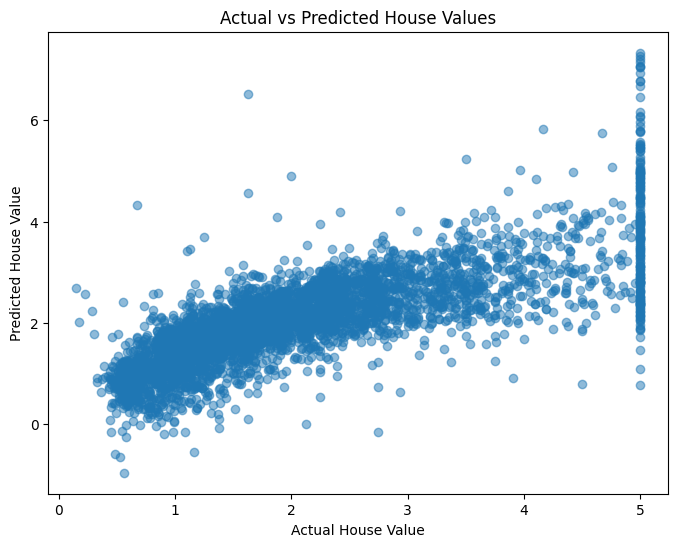

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [71]:
# Calculate residuals
residuals = y_test - y_pred

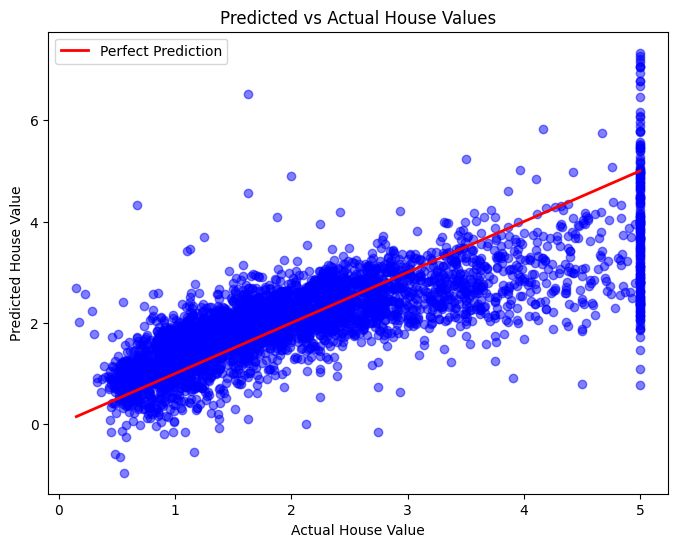

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5, color='blue')

# Perfect Prediction Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Predicted vs Actual House Values")
plt.legend()

plt.show()

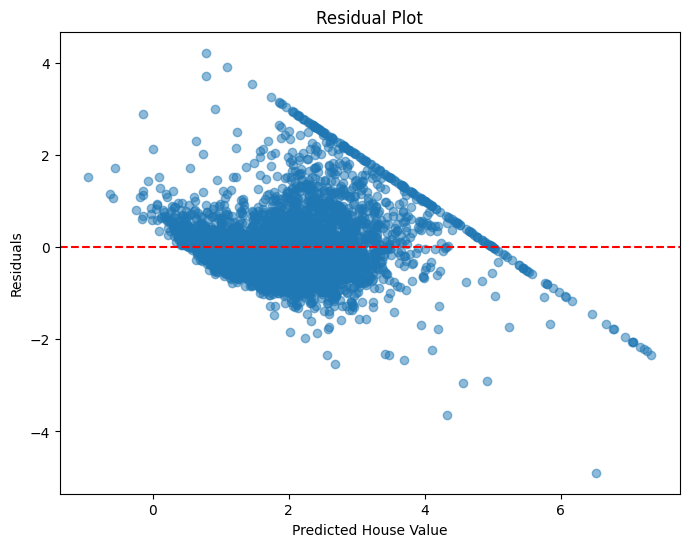

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

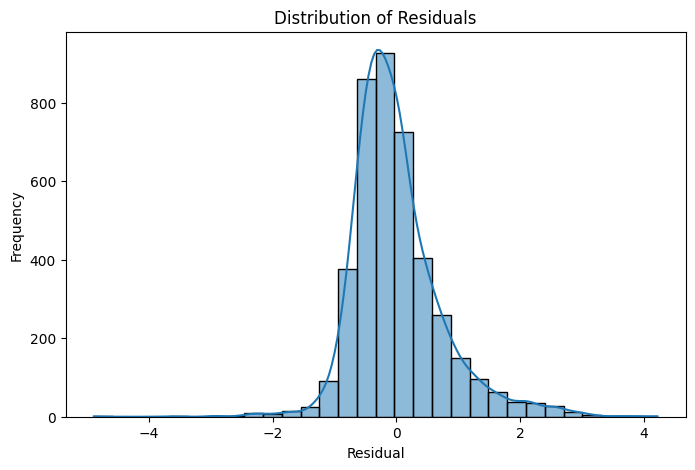

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, edgecolor='black',kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

*Part G - Conclusion and Reporting*

| Model                       |           MAE |          RMSE |      R² Score |
| --------------------------- | ------------: | ------------: | ------------: |
| Linear Regression           |    **0.5257** |    **0.7281** |    **0.5955** |


A comparison table was prepared to evaluate the performance of all regression models using MAE, RMSE, and R² Score. These metrics help compare the prediction accuracy of different models. Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates that the model explains a greater proportion of the variation in house prices. Based on the comparison, the best-performing model can be selected for deployment.

Recommendation ---

Based on the models evaluated in this project, the model with the highest R² Score and the lowest MAE and RMSE should be selected as the final model for deployment. Besides predictive performance, practical factors such as interpretability, training time, and robustness should also be considered. If the performance difference between models is small, a simpler and more interpretable model such as Linear Regression may be preferred. If a tree-based model achieves significantly better accuracy, it can be recommended despite its higher computational cost

***Project Summary***

This project focused on predicting median house values using the California Housing dataset. The dataset was explored using Exploratory Data Analysis (EDA), where missing values, duplicate records, and outliers were analyzed. Feature engineering was performed by creating new variables, and preprocessing techniques such as log transformation and feature scaling were applied to improve data quality. A Linear Regression model was trained using an 80:20 train-test split and evaluated using MAE, RMSE, and R² Score. The results showed that Median Income (MedInc) is the strongest factor influencing house prices, followed by housing characteristics such as Average Rooms (AveRooms) and geographical location. The model achieved an R² Score of 0.5955, indicating that it explains approximately 59.55% of the variation in median house values. Although the model provides reasonably accurate predictions, its estimates should be considered approximate because house prices are also affected by factors not included in the dataset. Overall, this project demonstrates that machine learning can effectively support house price estimation and assist in data-driven decision-making.

In [80]:
dat={
    "Hi":[1,0,0,0],
    "Nitish":[0,1,0,0],
    "Rahul":[0,0,1,0],
    "Ankit":[0,0,0,1]
}
df=pd.DataFrame(dat)
df

,Hi,Nitish,Rahul,Ankit
0,1,0,0,0
1,0,1,0,0
2,0,0,1,0
3,0,0,0,1
